Load Data

In [ ]:
import os
import json

# Make .kaggle folder if not exist
os.makedirs('/root/.kaggle', exist_ok=True)

# Write Kaggle API key
kaggle_token = {"username": "devinasawitrii", "key": "5300afb7789d065d05f22043a1ac4edc"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_token, f)

# Set file permission
os.chmod('/root/.kaggle/kaggle.json', 600)

# Install Kaggle CLI
!pip install -q kaggle

# Download competition dataset
!kaggle competitions download -c data-analytics-competition-find-it-2025

# Extract ZIP file
import zipfile
zip_path = "data-analytics-competition-find-it-2025.zip"
extract_to = "competition_data"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Show extracted files
print("Folder contents:", os.listdir(extract_to))


100% 172k/172k [00:00<00:00, 40.4MB/s]

Folder contents: ['dataset']


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Read the data
df_train = pd.read_csv("competition_data/dataset/train.csv")
df_target = pd.read_csv("competition_data/dataset/target.csv")
df = pd.concat([df_train, df_target], axis=1)

# Display the first few rows to verify the merge
df.head()



,developerCountry,countryCode,userRatingCount,primaryGenreName,downloads,deviceType,hasPrivacyLink,hasTermsOfServiceLink,hasTermsOfServiceLinkRating,isCorporateEmailScore,adSpent,appAge,averageUserRating,appContentBrandSafetyRating,appDescriptionBrandSafetyRating,mfaRating,coppaRisk
0,NORWAY,RO,127731,Sports,NaN,smartphone,True,True,low,99.0,14.017220,160.400000,4.0,medium,low,low,False
1,ADDRESS NOT LISTED IN PLAYSTORE,GLOBAL,0,Medical,50 - 100,GLOBAL,True,NaN,NaN,99.0,NaN,17.500000,0.0,NaN,low,low,False
2,UNITED ARAB EMIRATES,CZ,51143,Games,50000000 - 100000000,GLOBAL,True,True,low,0.0,31.883163,30.766667,4.0,NaN,low,low,False
3,GERMANY,GLOBAL,1074,Games,NaN,GLOBAL,True,NaN,NaN,99.0,NaN,71.533333,4.0,NaN,low,low,False
4,CANNOT IDENTIFY COUNTRY,GLOBAL,17,Tools,1000 - 5000,GLOBAL,True,NaN,NaN,99.0,NaN,52.400000,4.0,NaN,low,low,False


In [ ]:

# Show dataset info
df.info()

# Check unique values for each column
for col in df.columns:
    print(f"\n=== Column: {col} ===")
    print(f"Unique count: {df[col].nunique()}")
    print("Unique values:")
    print(df[col].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   developerCountry                 7000 non-null   object 
 1   countryCode                      6936 non-null   object 
 2   userRatingCount                  7000 non-null   int64  
 3   primaryGenreName                 7000 non-null   object 
 4   downloads                        4851 non-null   object 
 5   deviceType                       7000 non-null   object 
 6   hasPrivacyLink                   6250 non-null   object 
 7   hasTermsOfServiceLink            2365 non-null   object 
 8   hasTermsOfServiceLinkRating      2365 non-null   object 
 9   isCorporateEmailScore            5872 non-null   float64
 10  adSpent                          1321 non-null   float64
 11  appAge                           6950 non-null   float64
 12  averageUserRating   

Cleaning and Preparation Data

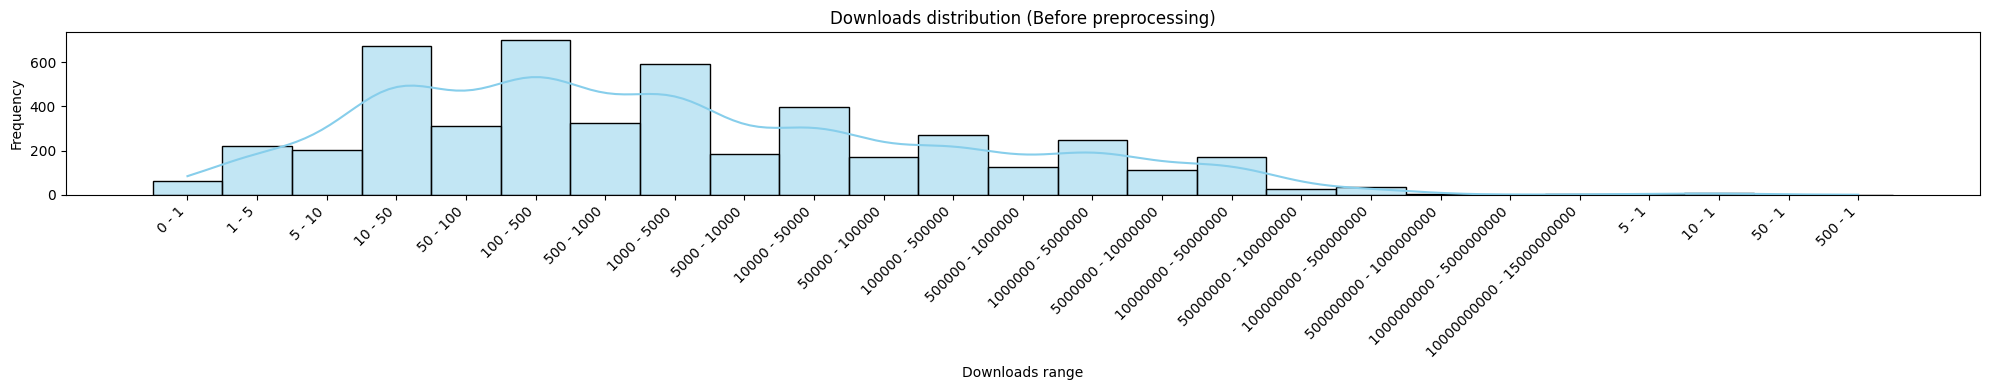

In [ ]:
# Coloumn downloads

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_plot_before = df.copy()

order = [
    '0 - 1', '1 - 5', '5 - 10', '10 - 50', '50 - 100',
    '100 - 500', '500 - 1000', '1000 - 5000',
    '5000 - 10000', '10000 - 50000', '50000 - 100000',
    '100000 - 500000', '500000 - 1000000',
    '1000000 - 5000000', '5000000 - 10000000',
    '10000000 - 50000000', '50000000 - 100000000',
    '100000000 - 500000000', '500000000 - 1000000000',
    '1000000000 - 5000000000',
    '10000000000 - 15000000000',

    # invalid
    '5 - 1', '10 - 1', '50 - 1', '500 - 1'
]

df_plot_before['downloads'] = pd.Categorical(
    df_plot_before['downloads'],
    categories=order,
    ordered=True
)

plt.figure(figsize=(20, 4))
sns.histplot(
    data=df_plot_before,
    x='downloads',
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.5
)

plt.title('Downloads distribution (Before preprocessing)', fontsize=12)
plt.xlabel('Downloads range')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Column developerCountry

import pandas as pd
import plotly.express as px

country_counts = df['developerCountry'].value_counts().reset_index()
country_counts.columns = ['developerCountry', 'count']

anomali = [
    'ADDRESS NOT LISTED IN PLAYSTORE',
    'CANNOT IDENTIFY COUNTRY',
    'STATUTORY MASKING ENABLED',
    'PERSONAL DATA, CAN NOT BE PUBLICLY DISCLOSED ACCORDING TO APPLICABLE LAWS.'
]
country_clean = country_counts[~country_counts['developerCountry'].isin(anomali)].copy()

bins   = [0, 10, 50, 100, float('inf')]
labels = ['1–10', '11–50', '51–100', '>100']

country_clean['kategori'] = pd.cut(
    country_clean['count'],
    bins=bins,
    labels=labels
)

color_map = {
    '1–10':   '#fcbba1',
    '11–50':  '#fb6a4a',
    '51–100': '#cb181d',
    '>100':   '#67000d'
}


fig = px.choropleth(
    country_clean,
    locations='developerCountry',
    locationmode='country names',
    color='kategori',
    color_discrete_map=color_map,
    category_orders={'kategori': labels},
    title='Distribusi Developer Aplikasi Berdasarkan Negara',
    hover_name='developerCountry',
    hover_data={'count': True, 'kategori': False}
)

fig.update_layout(
    title=dict(
        text='Distribusi Developer Aplikasi Berdasarkan Negara',
        font=dict(size=18, color='black', family='Arial'),
        x=0.5, xanchor='center'
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    geo=dict(
        showframe=True, framecolor='#cccccc',
        showcoastlines=True, coastlinecolor='#999999',
        showland=True, landcolor='white',
        showocean=True, oceancolor='#cce5f5',
        showcountries=True, countrycolor='#bbbbbb',
        bgcolor='white'
    ),
    legend=dict(
        title='Jumlah Aplikasi',
        bgcolor='white',
        bordercolor='#cccccc',
        borderwidth=1,
        font=dict(color='black', family='Arial')
    ),
    margin=dict(l=10, r=10, t=60, b=10),
    font=dict(color='black', family='Arial')
)

fig.show()

In [ ]:
print(df['developerCountry'].value_counts().to_dict())

{'ADDRESS NOT LISTED IN PLAYSTORE': 4338, 'CANNOT IDENTIFY COUNTRY': 769, 'UNITED STATES': 324, 'CHINA': 150, 'INDIA': 131, 'REPUBLIC OF KOREA': 95, 'FRANCE': 86, 'HONG KONG': 85, 'UNITED KINGDOM': 59, 'CYPRUS': 58, 'RUSSIAN FEDERATION': 52, 'TURKEY': 48, 'PAKISTAN': 47, 'VIET NAM': 46, 'JAPAN': 44, 'SINGAPORE': 42, 'UNITED ARAB EMIRATES': 39, 'GERMANY': 35, 'CANADA': 30, 'ISRAEL': 30, 'INDONESIA': 30, 'SPAIN': 22, 'JORDAN': 21, 'AUSTRALIA': 20, 'BANGLADESH': 19, 'NETHERLANDS': 16, 'SWITZERLAND': 16, 'THAILAND': 16, 'ITALY': 15, 'SWEDEN': 13, 'ICELAND': 13, 'UKRAINE': 13, 'MALAYSIA': 12, 'POLAND': 12, 'CZECH REPUBLIC': 12, 'ROMANIA': 10, 'ARGENTINA': 9, 'AUSTRIA': 8, 'PERU': 8, 'IRELAND': 8, 'BULGARIA': 8, 'FINLAND': 7, 'EGYPT': 7, 'PHILIPPINES': 7, 'NIGER': 7, 'GEORGIA': 7, 'DENMARK': 7, 'BRAZIL': 7, 'NEW ZEALAND': 6, 'CHILE': 6, 'LITHUANIA': 5, 'ESTONIA': 5, 'KAZAKHSTAN': 5, 'SERBIA': 5, 'PORTUGAL': 5, 'COLOMBIA': 4, 'SAUDI ARABIA': 4, 'SOUTH AFRICA': 4, 'MOROCCO': 4, 'ARMENIA': 4, '

/tmp/ipykernel_7410/2685160446.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_7410/2685160446.py:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



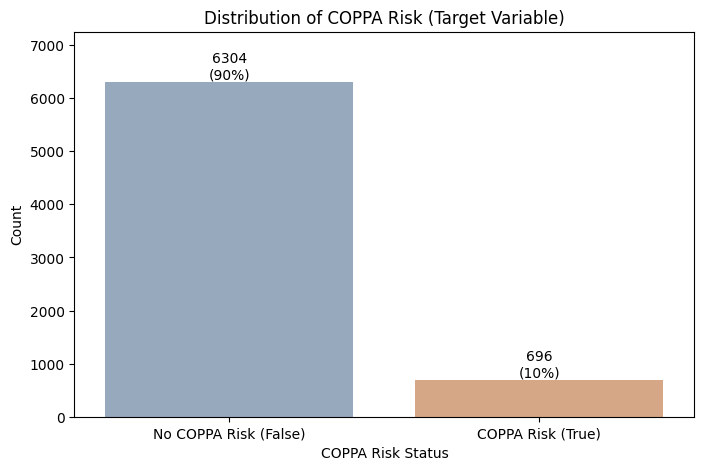

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization target variable

plt.figure(figsize=(8,5))

colors = ['#8FA9C4', '#E3A57A']

ax = sns.countplot(
    x='coppaRisk',
    data=df,
    palette=colors
)

ax.set_xticklabels([
    'No COPPA Risk (False)',
    'COPPA Risk (True)'
])

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.0f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

max_height = max([p.get_height() for p in ax.patches])
plt.ylim(0, max_height * 1.15)

plt.title('Distribution of COPPA Risk (Target Variable)')
plt.xlabel('COPPA Risk Status')
plt.ylabel('Count')

plt.show()

In [ ]:
print(df.duplicated().sum())

3


In [ ]:
# Drop duplicate data

before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"Duplikat yang dihapus: {before - after} baris")
print(f"Jumlah data sebelum: {before}")
print(f"Jumlah data sesudah: {after}")

Duplikat yang dihapus: 3 baris
Jumlah data sebelum: 7000
Jumlah data sesudah: 6997


In [ ]:
# Standardize developerCountry values
df['developerCountry'] = df['developerCountry'].replace({
    'VIET NAM': 'VIETNAM',
    'ADDRESS NOT LISTED IN PLAYSTORE': 'UNKNOWN',
    'CANNOT IDENTIFY COUNTRY': 'UNKNOWN',
    'PERSONAL DATA, CAN NOT BE PUBLICLY DISCLOSED ACCORDING TO APPLICABLE LAWS.': 'UNKNOWN',
    'STATUTORY MASKING ENABLED': 'UNKNOWN'
})
print(df['developerCountry'].value_counts())

# Drop unused column
df = df.drop(columns=['hasTermsOfServiceLinkRating'])

# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove invalid download values
invalid_vals = ['5 - 1', '10 - 1', '50 - 1',  '500 - 1']
df = df[~df['downloads'].isin(invalid_vals)].reset_index(drop=True)

developerCountry
UNKNOWN                5106
UNITED STATES           324
CHINA                   150
INDIA                   131
REPUBLIC OF KOREA        95
                       ... 
QATAR                     1
PALESTINE, STATE OF       1
BELARUS                   1
LEBANON                   1
MALDIVES                  1
Name: count, Length: 111, dtype: int64


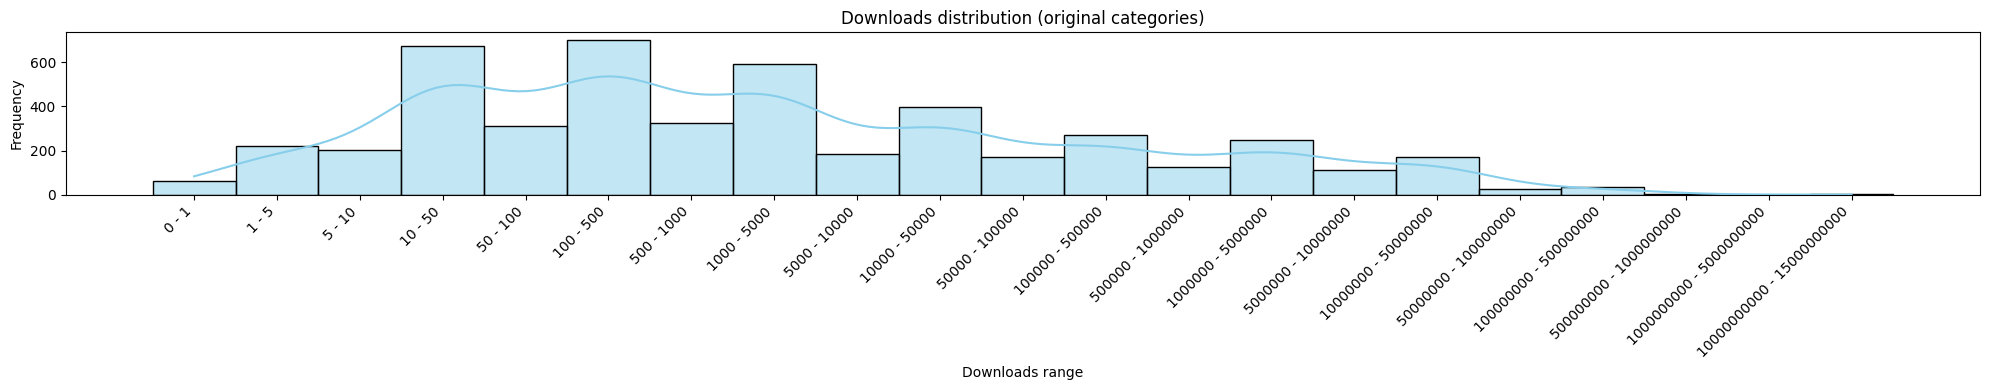

In [ ]:
# Visualization coloumn downloads
df_plot = df.copy()

# Sort
order = [
    '0 - 1', '1 - 5', '5 - 10',
    '10 - 50', '50 - 100', '100 - 500', '500 - 1000',
    '1000 - 5000', '5000 - 10000', '10000 - 50000',
    '50000 - 100000', '100000 - 500000', '500000 - 1000000',
    '1000000 - 5000000', '5000000 - 10000000',
    '10000000 - 50000000', '50000000 - 100000000',
    '100000000 - 500000000', '500000000 - 1000000000',
    '1000000000 - 5000000000', '10000000000 - 15000000000'
]

df_plot['downloads'] = pd.Categorical(
    df_plot['downloads'],
    categories=order,
    ordered=True
)

plt.figure(figsize=(20, 4))
sns.histplot(
    data=df_plot,
    x='downloads',
    kde=True,
    color='skyblue',
    edgecolor='black',
    alpha=0.5
)

plt.title('Downloads distribution (original categories)', fontsize=12)
plt.xlabel('Downloads range')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6981 entries, 0 to 6980
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   developerCountry                 6981 non-null   object 
 1   countryCode                      6917 non-null   object 
 2   userRatingCount                  6981 non-null   int64  
 3   primaryGenreName                 6981 non-null   object 
 4   downloads                        4834 non-null   object 
 5   deviceType                       6981 non-null   object 
 6   hasPrivacyLink                   6231 non-null   object 
 7   hasTermsOfServiceLink            2363 non-null   object 
 8   isCorporateEmailScore            5855 non-null   float64
 9   adSpent                          1321 non-null   float64
 10  appAge                           6931 non-null   float64
 11  averageUserRating                5751 non-null   float64
 12  appContentBrandSafet

/tmp/ipykernel_7410/1803689791.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_7410/1803689791.py:15: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



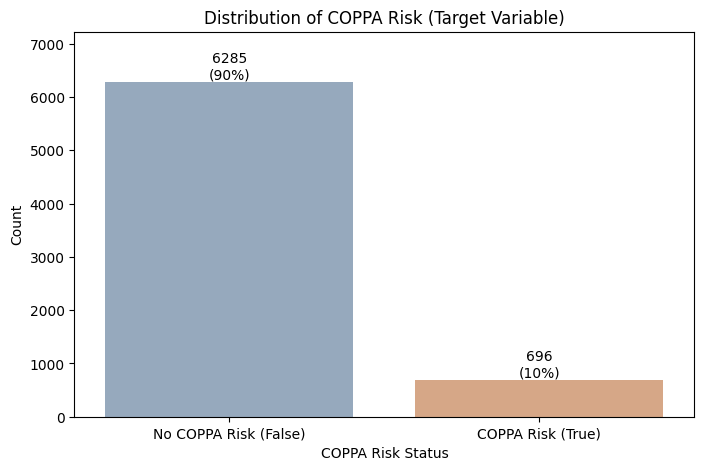

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization target variable after preparation data
plt.figure(figsize=(8,5))

colors = ['#8FA9C4', '#E3A57A']

ax = sns.countplot(
    x='coppaRisk',
    data=df,
    palette=colors
)

ax.set_xticklabels([
    'No COPPA Risk (False)',
    'COPPA Risk (True)'
])

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.0f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')


max_height = max([p.get_height() for p in ax.patches])
plt.ylim(0, max_height * 1.15)

plt.title('Distribution of COPPA Risk (Target Variable)')
plt.xlabel('COPPA Risk Status')
plt.ylabel('Count')

plt.show()

Baseline CatBoost

In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, classification_report, confusion_matrix

# Split features and label
X = df.drop(columns=['coppaRisk'])
y = df['coppaRisk']

# Identify categorical and numerical columns
cat_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in cat_features:
    X[col] = X[col].fillna("").astype(str)

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Baseline: CatBoost default tanpa optimasi
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import recall_score, classification_report, confusion_matrix

# Train langsung pakai X_train (80%), test pakai X_test (20%)
train_pool_baseline = Pool(X_train, y_train, cat_features=cat_features)

baseline_model = CatBoostClassifier(
    iterations=1000,
    random_seed=42,
    verbose=0
)
baseline_model.fit(train_pool_baseline)

# Evaluasi
baseline_preds = baseline_model.predict(X_test)


from sklearn.metrics import accuracy_score, recall_score

# Akurasi
print("Accuracy:", accuracy_score(y_test, baseline_preds))

# Recall
print("Recall:", recall_score(y_test, baseline_preds, average=None))

# Macro Recall
print("Macro Recall:", recall_score(y_test, baseline_preds, average='macro'))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, baseline_preds))

Accuracy: 0.9012168933428776
Recall: [0.98966614 0.10071942]
Macro Recall: 0.5451927805926959
Confusion Matrix:
 [[1245   13]
 [ 125   14]]


Build Model

In [ ]:
!pip install -q optuna catboost

import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, classification_report, confusion_matrix

# Split features and label
X = df.drop(columns=['coppaRisk'])
y = df['coppaRisk']

# Identify categorical and numerical columns
cat_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Categorical columns:", cat_features)
print("Numerical columns:", num_cols)

for col in cat_features:
    X[col] = X[col].fillna("").astype(str)

# Split 1: train 80%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Split 2: validation 10% test 10%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train : {len(X_train)} sampel")
print(f"Val   : {len(X_val)} sampel")
print(f"Test  : {len(X_test)} sampel")

# Optuna hyperparameter tuning (optimize macro recall)
train_pool_opt = Pool(X_train, y_train, cat_features=cat_features)
valid_pool_opt = Pool(X_val, y_val, cat_features=cat_features)
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1),
        "depth": trial.suggest_int("depth", 3, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 3, 9),
        "class_weights": [1.0, trial.suggest_float("minority_weight", 1.0, 10.0)],
        "eval_metric": "Recall",
        "random_seed": 42, # same randomness while training
        "early_stopping_rounds": 200,
        "verbose": 0, # no log progress training
        "iterations": 1000,
    }
    model = CatBoostClassifier(**params)
    model.fit(train_pool_opt, eval_set=valid_pool_opt, use_best_model=True)
    y_pred = model.predict(X_val)
    return recall_score(y_val, y_pred, average='macro')

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("\n Best Macro Recall (Optuna):", study.best_value)
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}") # key and value

# Train Mutually Disjoint Dataset
X_train_majority = X_train[y_train == 0]
X_train_minority = X_train[y_train == 1]

n_subsets = 9
majority_splits = np.array_split(X_train_majority, n_subsets)

models = []
best_params = study.best_params.copy()
best_params.update({
    "iterations": 1000,
    "class_weights": [1.0, best_params["minority_weight"]],
    "eval_metric": "Recall",
    "random_seed": 42,
    "early_stopping_rounds": 200,
    "verbose": 0
})
best_params.pop("minority_weight", None)

for i, split in enumerate(majority_splits):
    print(f"\n=== Training subset {i+1}/{n_subsets} ===")
    X_sub = pd.concat([split, X_train_minority])
    y_sub = np.concatenate([
        np.zeros(len(split)),
        np.ones(len(X_train_minority))
    ])
    train_pool_sub = Pool(X_sub, y_sub, cat_features=cat_features)
    model_sub = CatBoostClassifier(**best_params)
    model_sub.fit(train_pool_sub, use_best_model=True)
    models.append(model_sub)

# Soft voting for threshold optimization
probs_val = np.mean([model.predict_proba(X_val)[:, 1] for model in models], axis=0) # ambil hanya probabilitas prediksi untuk kelas 1 (True)

# Find best threshold for macro recall
threshold_results = []
best_thr, best_macro_recall = 0, 0
for thr in np.linspace(0.1, 0.9, 81):
    preds_thr = (probs_val >= thr).astype(int)
    r_macro = recall_score(y_val, preds_thr, average='macro')
    # Save threshold and metric
    threshold_results.append({"Threshold": round(thr, 2), "Macro Recall": round(r_macro, 4)})
    if r_macro > best_macro_recall:
        best_macro_recall, best_thr = r_macro, thr

# Convert to DataFrame
threshold_df = pd.DataFrame(threshold_results)
print("\nHasil Optimasi Threshold:")
print(threshold_df)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(threshold_df)

print(f"\n Best threshold: {best_thr:.3f} (Macro Recall={best_macro_recall:.4f})")

# Final evaluation
probs_test = np.mean([model.predict_proba(X_test)[:, 1] for model in models], axis=0)
y_pred_final = (probs_test >= best_thr).astype(int) # Determine class based by best threshold

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.5 MB/s eta 0:00:00
Categorical columns: ['developerCountry', 'countryCode', 'primaryGenreName', 'downloads', 'deviceType', 'hasPrivacyLink', 'hasTermsOfServiceLink', 'appContentBrandSafetyRating', 'appDescriptionBrandSafetyRating', 'mfaRating']
Numerical columns: ['userRatingCount', 'isCorporateEmailScore', 'adSpent', 'appAge', 'averageUserRating']
Train : 5584 sampel
Val   : 698 sampel
Test  : 699 sampel


[I 2026-05-12 17:19:44,070] A new study created in memory with name: no-name-b3e102ab-834d-4156-a6ab-1e22a7bd577b
[I 2026-05-12 17:19:57,730] Trial 0 finished with value: 0.8346236261837285 and parameters: {'learning_rate': 0.049082333243072554, 'depth': 8, 'l2_leaf_reg': 8.137027779964136, 'minority_weight': 3.3310382080133523}. Best is trial 0 with value: 0.8346236261837285.
[I 2026-05-12 17:20:02,820] Trial 1 finished with value: 0.8449574894587681 and parameters: {'learning_rate': 0.03754616250581826, 'depth': 7, 'l2_leaf_reg': 6.371625013830112, 'minority_weight': 3.8659686684131387}. Best is trial 1 with value: 0.8449574894587681.
[I 2026-05-12 17:20:13,022] Trial 2 finished with value: 0.6169212690951822 and parameters: {'learning_rate': 0.09508913720273417, 'depth': 7, 'l2_leaf_reg': 5.64148139154872, 'minority_weight': 1.559219134359764}. Best is trial 1 with value: 0.8449574894587681.
[I 2026-05-12 17:20:18,888] Trial 3 finished with value: 0.8286329808068938 and parameters: 


 Best Macro Recall (Optuna): 0.8498191285915071
Best Parameters:
   learning_rate: 0.04339785229610462
   depth: 9
   l2_leaf_reg: 5.752858227593044
   minority_weight: 4.207292261054885

=== Training subset 1/9 ===

=== Training subset 2/9 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.



=== Training subset 3/9 ===


...


=== Training subset 9/9 ===


You should provide test set for use best model. use_best_model parameter has been switched to false value.



Hasil Optimasi Threshold:
    Threshold  Macro Recall
0        0.10        0.7852
1        0.11        0.7892
2        0.12        0.7915
3        0.13        0.7939
4        0.14        0.7955
..        ...           ...
76       0.86        0.8240
77       0.87        0.8143
78       0.88        0.8062
79       0.89        0.8037
80       0.90        0.8028

[81 rows x 2 columns]


,Threshold,Macro Recall
0,0.10,0.7852
1,0.11,0.7892
2,0.12,0.7915
3,0.13,0.7939
4,0.14,0.7955
5,0.15,0.7963
6,0.16,0.7979
7,0.17,0.7987
8,0.18,0.7995
9,0.19,0.8019



 Best threshold: 0.810 (Macro Recall=0.8404)


In [ ]:
print("\n Evaluasi akhir di X_test:")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))


 Evaluasi akhir di X_test:
              precision    recall  f1-score   support

       False       0.99      0.78      0.87       629
        True       0.31      0.90      0.46        70

    accuracy                           0.79       699
   macro avg       0.65      0.84      0.67       699
weighted avg       0.92      0.79      0.83       699

[[491 138]
 [  7  63]]


In [ ]:
# Cek probabilitas tiap model untuk 1 sampel (sampel indeks 3)
sampel_idx = 3

print("Probabilitas kelas positif tiap model untuk sampel indeks 3:")
probs_per_model = []
for i, model in enumerate(models):
    prob = model.predict_proba(X_val)[:, 1][sampel_idx]
    probs_per_model.append(prob)
    print(f"  Model {i+1}: {prob:.4f}")

print(f"\nRata-rata (soft voting): {np.mean(probs_per_model):.4f}")
print(f"Hasil probs_val[{sampel_idx}]: {probs_val[sampel_idx]:.4f}")

Probabilitas kelas positif tiap model untuk sampel indeks 3:
  Model 1: 0.9334
  Model 2: 0.9600
  Model 3: 0.9585
  Model 4: 0.9608
  Model 5: 0.9537
  Model 6: 0.9630
  Model 7: 0.8181
  Model 8: 0.8794
  Model 9: 0.9763

Rata-rata (soft voting): 0.9337
Hasil probs_val[3]: 0.9337


In [ ]:
# Evaluate ensemble on test set
probs_test = np.mean([model.predict_proba(X_test)[:, 1] for model in models], axis=0)
final_preds = (probs_test >= best_thr).astype(int)

from sklearn.metrics import accuracy_score, recall_score
# Accuracy
print("Accuracy:", accuracy_score(y_test, final_preds))

# Recall
print("Recall:", recall_score(y_test, final_preds, average=None))

# Macro Recall
print("Macro Recall:", recall_score(y_test, final_preds, average='macro'))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))

Accuracy: 0.7925608011444921
Recall: [0.78060413 0.9       ]
Macro Recall: 0.8403020667726551
Confusion Matrix:
 [[491 138]
 [  7  63]]
